# Private SpiderBoost on Criteo (`dimma` adaptation)

Reference end-to-end run of Algorithm 2 (Arora et al., ICML 2023) on the Criteo 1M sample, using the `dimma` library. This notebook is the adapted version of `private_spider_boost_criteo/notebooks/train_private_spiderboost.ipynb`.

## 1. Imports

In [1]:
import sys
from pathlib import Path

# Make the local model.py and visualization.py importable.
HERE = Path('.').resolve()
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

import jax
import jax.numpy as jnp
import numpy as np
from sklearn.metrics import roc_auc_score

import dimma
from dimma import TrainConfig, compute_noise_scales
from dimma.datasets import load_criteo

import model
import visualization as viz

## 2. Hyperparameters

We use a modest `T=200` so the notebook runs in a few minutes on CPU. Increase `T` for higher-fidelity demos.

In [2]:
FIGS_DIR = HERE / 'figs'
FIGS_DIR.mkdir(exist_ok=True)

HIDDEN_DIMS = (64, 32)

config = TrainConfig(
    epsilon=10.0,
    delta=1.0 / (1.1 * 800_000),
    L0=3.0,
    L1=5.0,
    T=200,
    q=30,
    b1=8192,
    b2=512,
    eta=0.01,
    seed=0,
)
config

TrainConfig(epsilon=10.0, delta=1.1363636363636362e-06, L0=3.0, L1=5.0, T=200, q=30, b1=8192, b2=512, eta=0.01, seed=0, margin_sigmas=6.0)

## 3. Load data

Downloads on first call (~30 MB) and caches locally. License notice is printed to stderr on first download per process.

In [3]:
data = load_criteo(features='integer', test_fraction=0.2, seed=0, device='cpu')
x_train, y_train = data.x_train, data.y_train
x_test, y_test = data.x_test, data.y_test
n_train, d = x_train.shape
print(f'n_train={n_train}  d={d}  n_test={x_test.shape[0]}')

n_train=800000  d=13  n_test=200000


## 4. Setup

Build initial parameters; define the per-sample loss; compute noise scales for the target (`epsilon`, `delta`).

In [4]:
key = jax.random.PRNGKey(config.seed)
init_params = model.init_params(key, input_dim=d, hidden_dims=HIDDEN_DIMS)
per_sample_loss_fn = model.per_sample_bce_loss

noise_scales = compute_noise_scales(
    L0=config.L0, L1=config.L1,
    epsilon=config.epsilon, delta=config.delta,
    T=config.T, q=config.q, n=n_train,
    b1=config.b1, b2=config.b2,
)
print(f'sigma1     = {noise_scales.sigma1:.4e}')
print(f'sigma2     = {noise_scales.sigma2:.4e}')
print(f'sigma2_hat = {noise_scales.sigma2_hat:.4e}')

sigma1     = 1.3549e-04
sigma2     = 3.6130e-03
sigma2_hat = 4.3356e-03


## 5. Train

Run the SpiderBoost loop. We use the strict Poisson sampler (`sampler='poisson'`) — the default — and an empty callback.

In [5]:
result = dimma.train(
    x_train, y_train,
    per_sample_loss_fn=per_sample_loss_fn,
    init_params=init_params,
    config=config,
    noise_scales=noise_scales,
    sampler='poisson',
)
print(f'wall time: {sum(result.history.wall_time_s):.1f} s')
print(f'output_step (random iterate t*): {result.history.output_step}')
print(f'final ||grad||: {result.history.grad_norm[-1]:.4f}')

wall time: 3.6 s
output_step (random iterate t*): 82
final ||grad||: 0.0969


## 6. Evaluate

Compute test ROC-AUC for both the final iterate and the random iterate selected per Algorithm 2's output rule.

In [6]:
@jax.jit
def predict_logits(params, x):
    return model.forward(params, x)

def evaluate_auc(params, x, y):
    logits = predict_logits(params, x)
    return float(roc_auc_score(np.asarray(y), np.asarray(logits)))

auc_final = evaluate_auc(result.params_final, x_test, y_test)
auc_random = evaluate_auc(result.params_random, x_test, y_test)
print(f'Test ROC-AUC (final iterate w_T):      {auc_final:.4f}')
print(f'Test ROC-AUC (random iterate w_bar):   {auc_random:.4f}')

Test ROC-AUC (final iterate w_T):      0.6414
Test ROC-AUC (random iterate w_bar):   0.6126


## 7. Plots

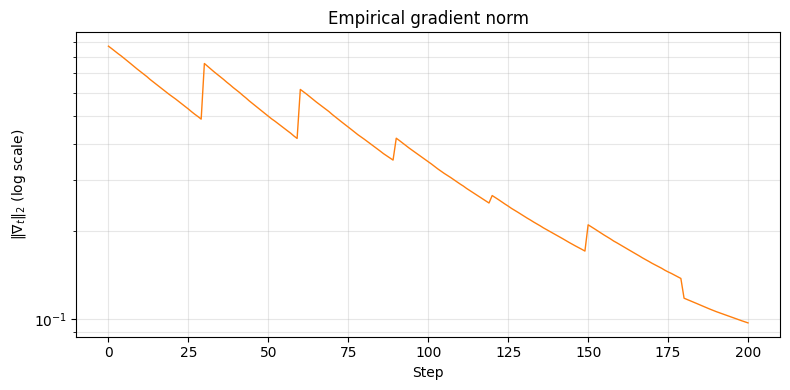

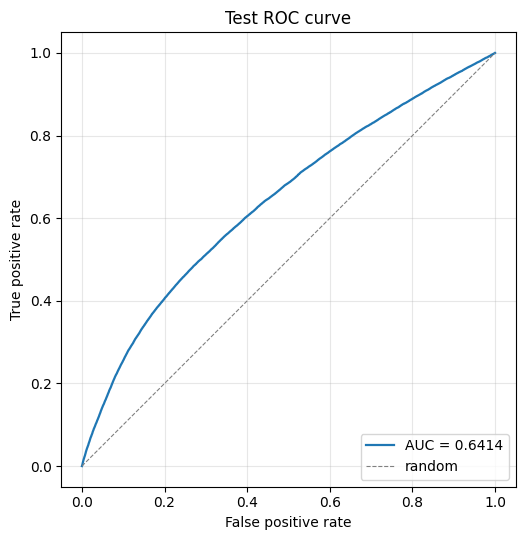

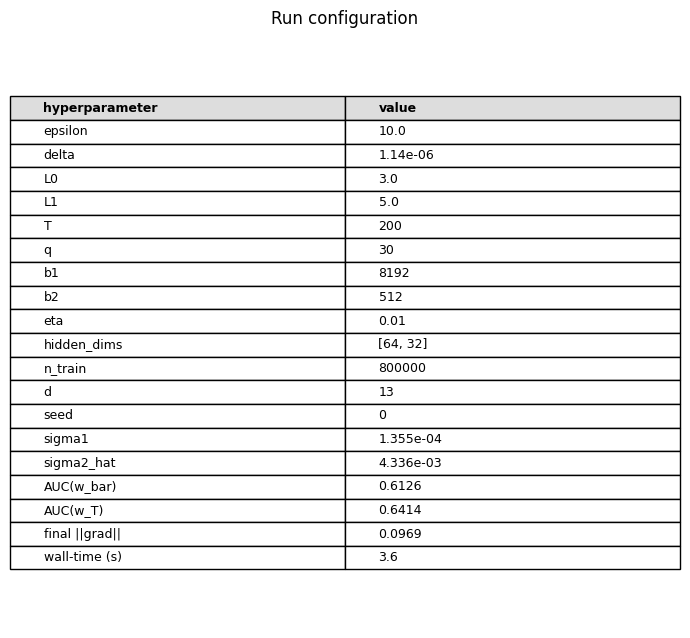

In [7]:
_ = viz.plot_gradient_norm(result.history.grad_norm,
                            FIGS_DIR / 'gradient_norm.png')

logits_test = np.asarray(predict_logits(result.params_final, x_test))
_ = viz.plot_roc_curve(np.asarray(y_test), logits_test, auc_final,
                        FIGS_DIR / 'roc_curve.png')

summary = {
    'epsilon': config.epsilon, 'delta': f'{config.delta:.2e}',
    'L0': config.L0, 'L1': config.L1,
    'T': config.T, 'q': config.q,
    'b1': config.b1, 'b2': config.b2,
    'eta': config.eta, 'hidden_dims': list(HIDDEN_DIMS),
    'n_train': n_train, 'd': d, 'seed': config.seed,
    'sigma1': f'{noise_scales.sigma1:.3e}',
    'sigma2_hat': f'{noise_scales.sigma2_hat:.3e}',
    'AUC(w_bar)': f'{auc_random:.4f}',
    'AUC(w_T)': f'{auc_final:.4f}',
    'final ||grad||': f'{result.history.grad_norm[-1]:.4f}',
    'wall-time (s)': f'{sum(result.history.wall_time_s):.1f}',
}
_ = viz.plot_hyperparameter_summary(summary,
                                     FIGS_DIR / 'hyperparameters.png')

**Note on the missing training-loss plot.** The original notebook tracked per-step batch BCE inside the loop. `dimma.train` does not expose the per-step batch to the callback, so the `plot_training_loss` figure cannot be reproduced exactly. Extending `StepInfo` to carry the batch is a candidate library enhancement; for now the plot is omitted.